### Парная линейная регрессия

#### Цель работы

Познакомиться с основными понятиями задачи регрессии и метода градиентного спуска.

#### Содержание работы

1. Загрузить данные из тектовых файлов.
2. Создать и построить модель парной линейной регрессии с использованием метода градиентного спуска.
3. Оценить на графике качество построенной модели.
4. Построить кривые обучения.

Для полноценной работы с регрессионным анализом данных на потребуются следующие библиотеки языка Python:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Для начала считаем данные о котировке двух инструментов из csv-файла и посмотрим формат файла с данными - состав и названия полей:

In [23]:
x = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv')
y = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv')

In [24]:
x.head()

,Unnamed: 0,0
0,0,1.462108
1,1,1.133769
2,2,-2.301539
3,3,1.744812
4,4,0.042214


Аналогичная картина наблюдается и в переменной y. Здесь мы видим две проблемы. Во-первых, при считывании данных из файла pandas добавил специальный стоблец с номером строки. Он нам не нужен. Во-вторых, мы получили объекты типа DataFrame, а для дальнейшей работы нам нужен объект типа Series. Эти проблемы можно решить разными способами, но прощевсего взять из получившихся датафреймов одну нужную колонку:

In [2]:
x = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv', index_col=0)['0']
y = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv', index_col=0)['0']

Затем выделим из получившегося объединенного датасета результативный и факторный признак. В нашем случае это будут цены закрытия двух этих инструментов:

In [26]:
x.head()

0    1.462108
1    1.133769
2   -2.301539
3    1.744812
4    0.042214
Name: 0, dtype: float64

Для визуального представления совместного распределения значений используемых переменных построим график зависимости одной переменной от другой:

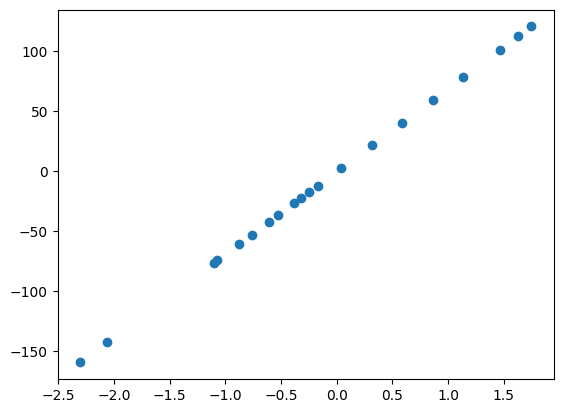

In [27]:
plt.figure()
plt.scatter(x, y)
plt.show()

Мы видим, что линейная зависимость прослеживается в данных. Значит, мы можем продолжать и использовать парную линейную регрессию.

Начнем строить класс, который будет реализовывать метод парной линейной регрессии:

In [28]:
class Model(object):
    def __init__(self):
        self.b0 = 0
        self.b1 = 0
    def predict(self, x):
        return self.b0 + self.b1 * x
    def error(self, X, Y):
        return sum((self.predict(X) - Y)**2) / (2 * len(X))
    def fit(self, X, Y):  
        alpha = 0.1
        dJ0 = sum(self.predict(X) - Y) /len(X)
        dJ1 = sum((self.predict(X) - Y) * X) /len(X)
        self.b0 -= alpha * dJ0
        self.b1 -= alpha * dJ1

Здесь мы определили конструктор класса, который запоминает в полях экземпляра параметры регрессии. В дальнейшем мы сможем расширять функциональность этого класса сколь угодно много.

Реализуем метод, который принимает значение входной переменной и возвращает теоретическое значение выходной - это прямое действие нашей регрессии - метод предсказания результата по факторам (в случае парной регрессии - по одному фактору):

Теперь зададим функцию ошибки:

В данном случае мы используем простую функцию ошибки - среднеквадратическое отклонение (mean squared error, MSE). Можно использовать и другие функции ошибки. Именно вид функции ошибки будет определять то, какой вид регрессии мы реализуем. Существует много разных вариаций простого алгоритма регрессии. О большинстве распространенных методах регрессии можно почитать в официальной документации sklearn.

Теперь реализуем метод градиентного спуска. Он должен принимать массив X и массив Y и обновлять параметры регрессии в соответствии в формулами градиентного спуска:

Здесь мы используем некоторое произвольное число - alpha - скорость обучения. О выборе конкретного значения alpha - скорости обучения мы еще поговорим позднее.

Давайте создадим объект регрессии и проверим начальное значение ошибки:

In [29]:
hyp = Model()
print(hyp.predict(0))
print(hyp.predict(100))
J = hyp.error(x, y)
print("initial error:", J)

0
0
initial error: 2937.6446095153397



Как мы видим, для начала оба параметра регрессии равны нулю. Конечно, такая модель не дает надежных предсказаний, но в этом и состоит метод градиентного спуска: начиная с любого решения мы постепенно его улучшаем и приходим к оптимальному решению.

Теперь изобразим нашу регрессию на графике:

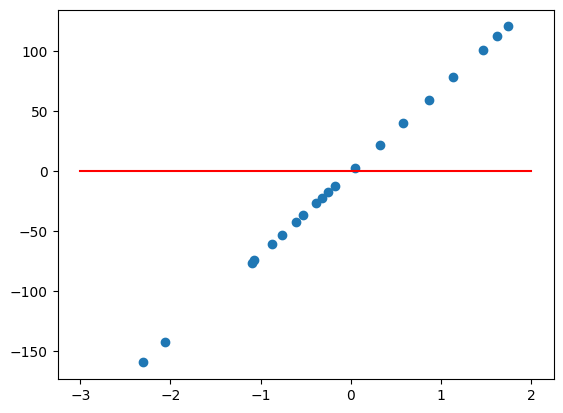

In [30]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)
plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

Как и ожидалось, мы видим горизонтальную линию - в нашей примитивной модели пока для любого входного значения, выходное всегда будет 0.

Теперь все готово к запуску градиентного спуска.

In [31]:
hyp.fit(x, y)
J = hyp.error(x, y)
print("error after gradient descent:", J)

error after gradient descent: 2253.745680891855


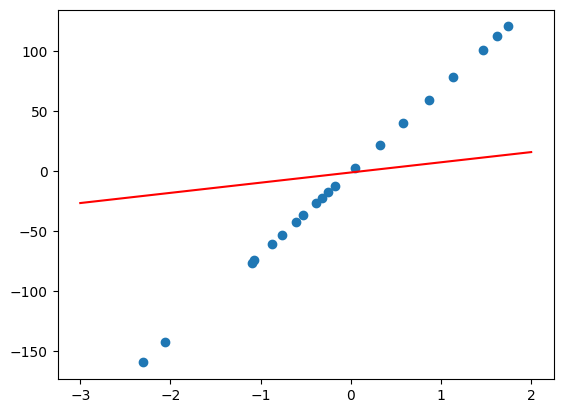

In [32]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)
plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

Как мы видим, численное значение ошибки значительно уменьшилось. Да и линия на графике существенно приблизилось к точкам. Конечно, наша модель еще далека от совершенства. Мы прошли всего лишь одну итерацию градиентного спуска. Модифицируем метод так, чтобы он запускался в цикле определенное количество раз:

In [3]:
class Model(object):
    def __init__(self):
        self.b0 = 0
        self.b1 = 0
    def predict(self, X):
        return self.b0 + self.b1 * X
    def error(self, X, Y):
        return sum((self.predict(X) - Y)**2) / (2 * len(X))
    def fit(self, X, Y, alpha=0.001, max_steps=10000):
        steps = []
        errors = []
        for step in range(1, max_steps + 1):
            dJ0 = sum(self.predict(X) - Y) / len(X)
            dJ1 = sum((self.predict(X) - Y) * X) / len(X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1
            steps.append(step)
            errors.append(self.error(X, Y))
        return steps, errors

Заодно мы расширили функциональность этого метода так, чтобы он возвращал массив ошибок на каждой итерации спуска и номер итерации. Это будет нам полезно для построения графика обучения.

Запустим наш градиентный спуск:

In [4]:
hyp = Model()
steps, errors = hyp.fit(x, y)
J = hyp.error(x, y)
print("error after gradient descent:", J)

error after gradient descent: 2.7769753060560073e-06


Как мы видим, теперь ошибка снизилась гораздо больше. Однако, она все еще не достигла нуля. Заметим, что нулевая ошибка не всегда возможна в принципе из-за того, что точки данных не всегда будут располагаться на одной линии. Кроме того, алгоритм градиентного спуска - численный и сходится в пределе, то есть после бесконечного количества повторений. Нужно стремиться не к нулевой, а к минимально возможной ошибке.

Посмотрим, как теперь наша регрессия выглядит на графике:

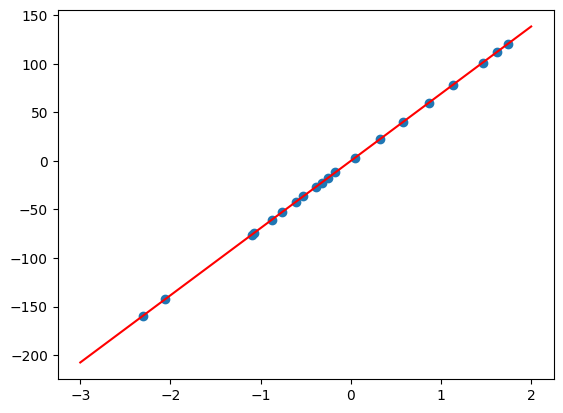

In [35]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)
plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

Уже значительно лучше. Линия регрессии довольно похожа на оптимальную. Так ли это на самом деле, глядя на график, сказать сложно, для этого нужно проанализировать, как ошибка регрессии менялась со временем:

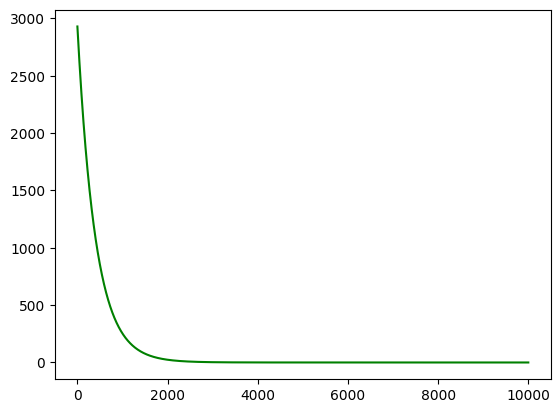

In [36]:
plt.figure()
plt.plot(steps, errors, 'g')
plt.show()

На графике наглядно видно, что в начале обучения ошибка падала быстро, но в ходе градиентного спуска она вышла на плато. Учитывая, что мы используем гладкую функцию ошибки второго порядка, это свидетельствует о том, что мы достигли локального оптимума и дальнейшее повторение алгоритма не принесет улучшения модели.

#### Контрольные вопросы

##### 1. Сформулируйте, в чем состоит задача регрессии, придумайте несколько примеров.
Задача регрессии – предсказание непрерывной величины по входным признакам. Примеры: прогноз цены квартиры, предсказание температуры, оценка времени доставки.

##### 2. Что такое метод градиентного спуска?
Метод градиентного спуска – итерационный алгоритм оптимизации, который движется в сторону антиградиента функции потерь, чтобы найти её минимум.

##### 3. Что такое скорость обучения в методе градиентного спуска?
Скорость обучения (alpha) – размер шага при обновлении параметров. Маленькая alpha → медленная сходимость, большая → риск расходимости.

##### 4. Какие функции ошибки используются в регрессионных моделях и почему именно такие?
Функции ошибки – MSE, MAE, Huber и др. MSE используется часто, потому что она гладкая, дифференцируемая и сильно штрафует большие ошибки.

##### 5. Что показывает конкретное значение ошибки регрессии?
Значение ошибки регрессии – показывает среднее отклонение предсказаний модели от реальных значений. Чем меньше, тем лучше.

##### 6. Что показывает график обучения и зачем его строить?
График обучения – показывает динамику ошибки в процессе обучения. Позволяет оценить сходимость, скорость обучения и момент выхода на плато.
